# 050 — Regional Delta Analysis

Complements the raw pixel-wise delta `|real_IR − predicted_IR|` with the regional
analysis proposed in `note.md`: a local luminance/contrast/structure decomposition
(reusing the SSIM machinery), per-window z-score normalisation, and per-zone
distribution comparison — implemented in `scripts/delta_analysis.py`.

The goal is to separate genuine hidden-detail signal (underdrawings, pentimenti,
reused supports) from substrate/acquisition-driven gray-level shifts that a raw
absolute delta cannot distinguish.

**No trained model is available yet** (`020_training.ipynb` training run still
pending). This notebook is runnable today against a **synthetic** RGB/IR pair that
exercises the same code path — a uniform gray-level offset region (should score low
on `structural_delta`) and a structurally-altered region (should score high). Once a
checkpoint exists in `models/<arch>/best_model.keras`, set `USE_SYNTHETIC_DATA = False`
in section 2 to run the analysis on a real predicted/real IR pair instead — no other
cell needs to change.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image

from scripts.config import settings
from scripts.dataset import pad_to_multiple
from scripts.delta_analysis import analyze_delta
from scripts.inference_utils import predict_with_overlap
from scripts.trainer import load_model
from scripts.visualization import plot_delta, plot_delta_analysis, plot_predictions

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load model (optional)

Attempts to load the best checkpoint for `ARCH`. If none exists yet (training in
`020_training.ipynb` hasn't produced `models/<arch>/best_model.keras`), `model` is set
to `None` and section 2 falls back to synthetic data automatically.

In [3]:
ARCH = "efficientnet_unet"  # "unet" | "resunet" | "attention_unet" | "efficientnet_unet"

try:
    model = load_model(
        ARCH,
        model_dir=settings.MODELS_DIR,
        lr=settings.LEARNING_RATE,
        loss_alpha=settings.LOSS_ALPHA,
    )
    print(f"Loaded: {model.name} | Parameters: {model.count_params():,}")
except (FileNotFoundError, OSError) as exc:
    model = None
    print(f"No trained checkpoint found for '{ARCH}' ({exc}).")
    print("Falling back to synthetic data in section 2 — rerun once training completes.")

2026-08-11 23:02:52.190522: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-11 23:02:52.190543: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-11 23:02:52.190548: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-11 23:02:52.190562: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-11 23:02:52.190572: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Loaded: efficientnet_unet | Parameters: 8,325,556


## 2. Real or synthetic IR pair

If `model` was loaded and a paired image exists in `data/test/rgb/` /
`data/test/ir/`, runs real inference via `predict_with_overlap`. Otherwise generates a
synthetic `(real_ir, pred_ir)` pair with two deliberately different regions:

- a **gray-level shift** region (same texture, offset mean) — a stand-in for a
  substrate/acquisition effect;
- a **structurally-altered** region (uncorrelated pattern) — a stand-in for a genuine
  hidden mark.

This keeps the rest of the notebook runnable end-to-end regardless of training status.

Set `IMAGE_STEM` below to pick a specific image from `data/test/rgb/` by filename stem
(e.g. `"00"` for `00.jpg`) — see the `Available pairs` list printed by the previous
cell. Leave it `None` to use the first available pair.

In [4]:
TEST_RGB_DIR = project_root / "data" / "test" / "rgb"
TEST_IR_DIR  = project_root / "data" / "test" / "ir"

rgb_paths = sorted(TEST_RGB_DIR.glob("*.jpg")) if TEST_RGB_DIR.exists() else []
test_pairs = [(p, TEST_IR_DIR / p.name) for p in rgb_paths if (TEST_IR_DIR / p.name).exists()]

USE_SYNTHETIC_DATA = model is None or not test_pairs
print(f"USE_SYNTHETIC_DATA = {USE_SYNTHETIC_DATA}")
print(f"Available pairs: {[p.stem for p, _ in test_pairs]}")

USE_SYNTHETIC_DATA = False
Available pairs: ['case', 'green', 'modern', 'total']


In [6]:
IMAGE_STEM = 'green'  # e.g. "00" — pick a specific image from data/test/rgb/; None = first available


def make_synthetic_pair(size: int = 256, seed: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """Build a synthetic (real_ir, pred_ir) pair for a dry run of the analysis.

    Parameters
    ----------
    size : int
        Side length of the square images.
    seed : int
        Random seed for the noise and the uncorrelated patch.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        ``(real_ir, pred_ir)``, each shape ``(size, size)``, values in ``[0, 1]``.
    """
    rng = np.random.default_rng(seed)
    x, y = np.meshgrid(np.linspace(0, 6 * np.pi, size), np.linspace(0, 6 * np.pi, size))
    texture = 0.5 + 0.25 * np.sin(x) * np.cos(y)
    real = np.clip(texture + rng.normal(0, 0.02, size=(size, size)), 0.0, 1.0)

    pred = real.copy()

    # Gray-level shift region: same structure, offset mean (substrate/acquisition-like).
    s = size // 4
    pred[s : 2 * s, s : 2 * s] = np.clip(pred[s : 2 * s, s : 2 * s] - 0.2, 0.0, 1.0)

    # Structurally-altered region: uncorrelated pattern (genuine-mark-like).
    pred[3 * s : 4 * s, 3 * s : 4 * s] = rng.random((s, s))

    return real.astype(np.float32), pred.astype(np.float32)


def select_pair(pairs: list[tuple[Path, Path]], stem: str | None) -> tuple[Path, Path]:
    """Return the (rgb, ir) path pair matching ``stem``, or the first pair if None.

    Parameters
    ----------
    pairs : list[tuple[Path, Path]]
        Candidate ``(rgb_path, ir_path)`` pairs.
    stem : str or None
        Filename stem to select, or None for the first pair.

    Returns
    -------
    tuple[Path, Path]

    Raises
    ------
    ValueError
        If ``stem`` doesn't match any available pair.
    """
    if stem is None:
        return pairs[0]
    matches = [pair for pair in pairs if pair[0].stem == stem]
    if not matches:
        available = [p.stem for p, _ in pairs]
        raise ValueError(f"IMAGE_STEM='{stem}' not found. Available: {available}")
    return matches[0]


if USE_SYNTHETIC_DATA:
    ir_real, ir_pred = make_synthetic_pair()
    rgb = np.stack([ir_real] * 3, axis=-1)  # placeholder RGB for display only
    pair_label = "synthetic"
else:
    rgb_path, ir_path = select_pair(test_pairs, IMAGE_STEM)
    rgb = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.0
    ir_real = np.array(Image.open(ir_path).convert("L")).astype(np.float32) / 255.0

    padded, _ = pad_to_multiple(tf.constant(rgb), multiple=settings.PATCH_MULTIPLE)
    ir_pred_full = model.predict(padded[tf.newaxis, ...], verbose=0)[0]
    h, w = ir_real.shape
    ir_pred = ir_pred_full[:h, :w, 0]
    pair_label = rgb_path.stem

print(f"Pair: {pair_label} | shape: {ir_real.shape}")

2026-08-11 23:03:09.431574: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Pair: green | shape: (2349, 3263)


## 3. Baseline: RGB / real IR / predicted IR and raw delta

Same visualisation as `040_inference.ipynb`, for reference before the regional
analysis.

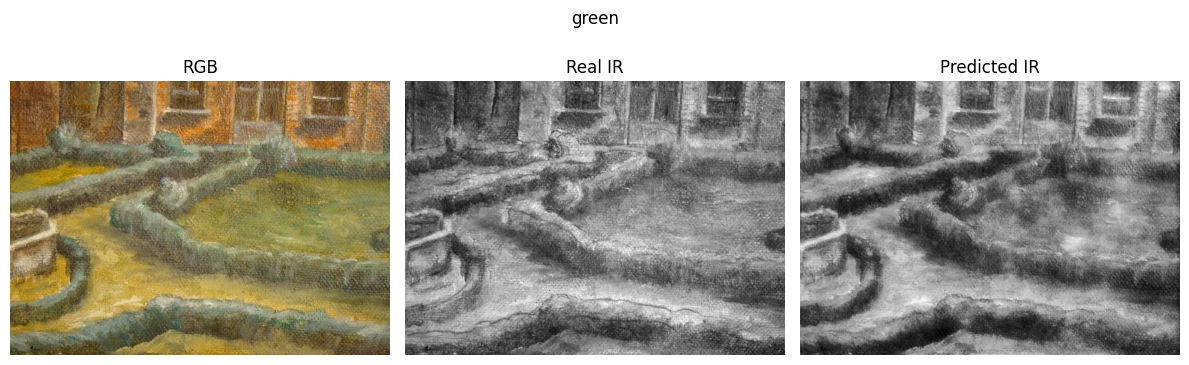

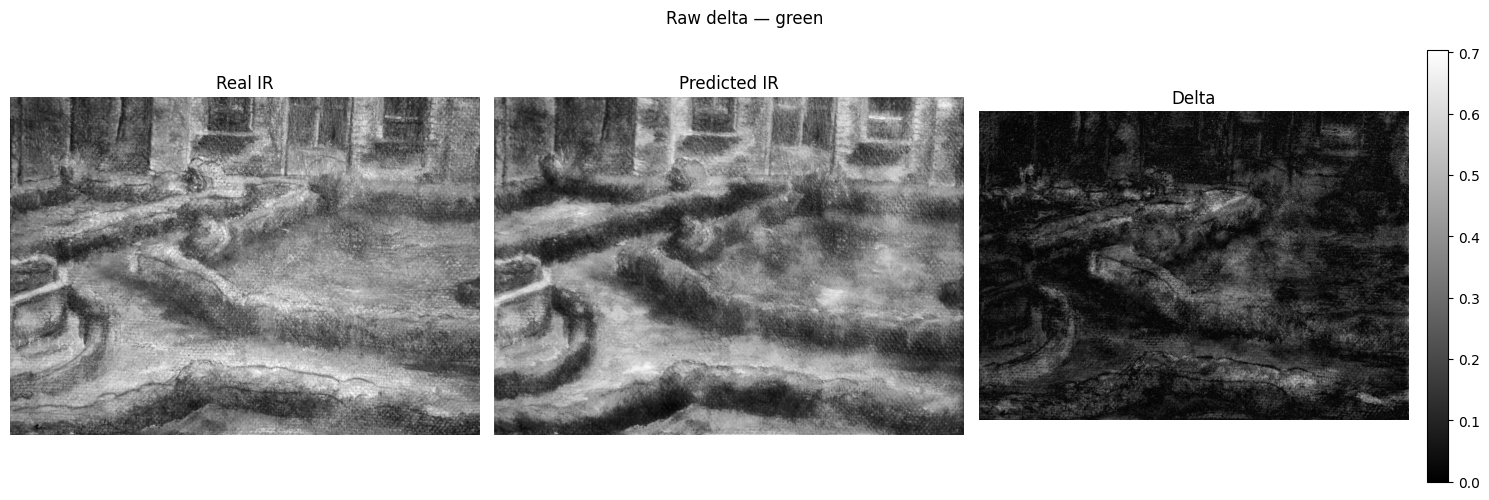

In [7]:
fig = plot_predictions(rgb, ir_real, ir_pred, title=pair_label)
plt.show()

fig = plot_delta(ir_real, ir_pred, title=f"Raw delta — {pair_label}")
plt.show()

## 4. Regional delta analysis

`analyze_delta` returns:

- `structural_delta` — `1 - structure_map` from the local SSIM decomposition; the
  "hidden detail" indicator, largely insensitive to local gray-level shifts;
- `normalized_delta` — delta between per-window z-score normalised images;
- `zone_distribution_map` — per-zone Wasserstein distance between real/predicted pixel
  distributions;
- `confidence_map` — agreement between `raw_delta` and `structural_delta` (high where
  both techniques agree a region stands out).

On the synthetic pair, the gray-level-shift region should score low on
`structural_delta` despite a high `raw_delta`, and the structurally-altered region
should score high on both.

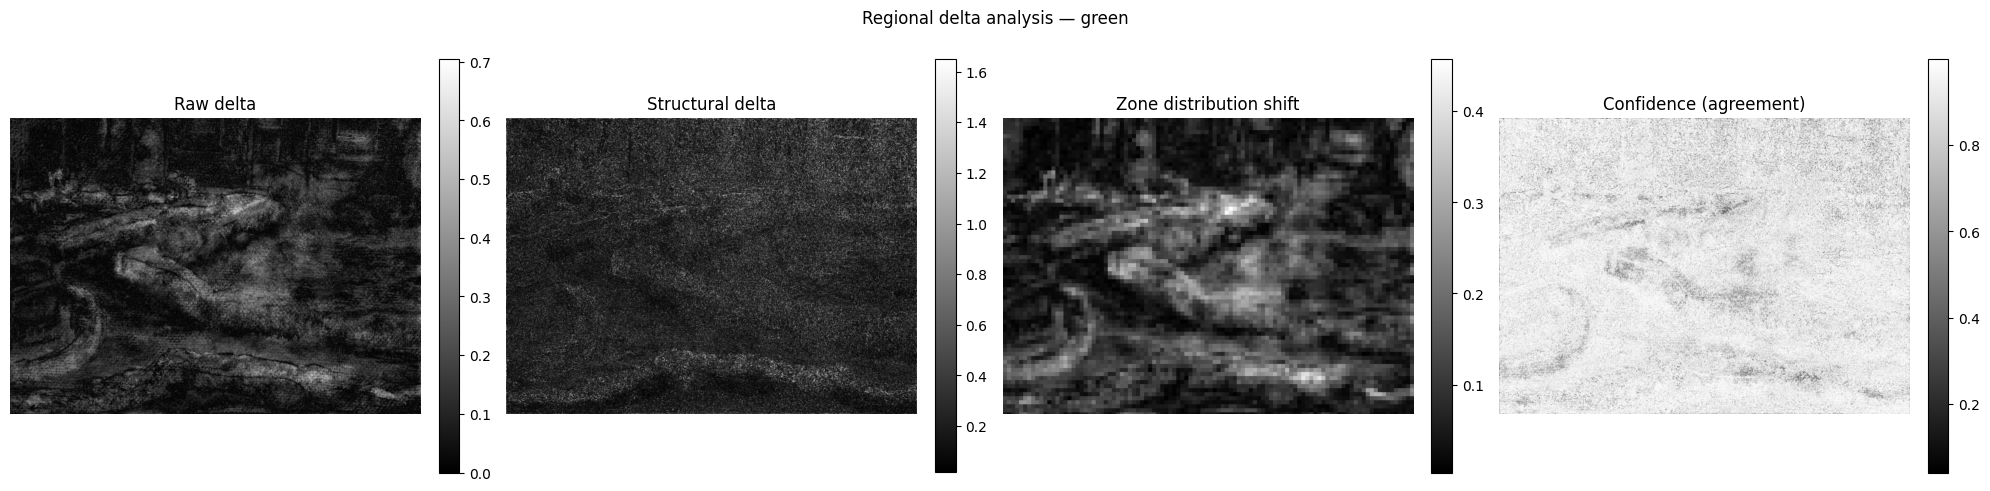

In [8]:
result = analyze_delta(ir_real, ir_pred, window_size=11, zone_size=32)

fig = plot_delta_analysis(result, title=f"Regional delta analysis — {pair_label}")
plt.show()

## 5. Luminance / contrast / structure maps

The three SSIM components computed separately, per local window.

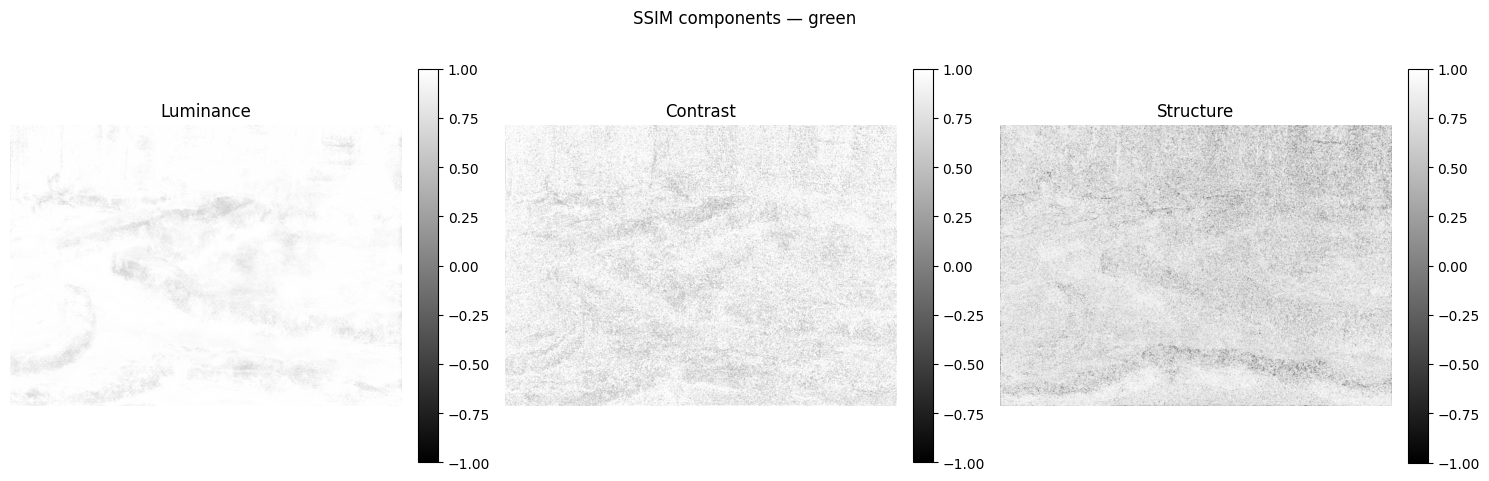

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"SSIM components — {pair_label}")

for ax, (name, data) in zip(
    axes,
    [
        ("Luminance", result.luminance_map),
        ("Contrast", result.contrast_map),
        ("Structure", result.structure_map),
    ],
):
    im = ax.imshow(data, cmap="gray", vmin=-1, vmax=1)
    ax.set_title(name)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 6. Top zones by distribution shift

Ranks the non-overlapping analysis zones by Wasserstein distance — a shortlist for a
conservator to inspect first, independent of the raw delta magnitude.

In [ ]:
ZONE_SIZE = 32
TOP_N = 10

zone_scores = []
h, w = result.zone_distribution_map.shape
for zy in range(0, h, ZONE_SIZE):
    for zx in range(0, w, ZONE_SIZE):
        score = float(result.zone_distribution_map[zy, zx])
        zone_scores.append((score, zy, zx))

zone_scores.sort(reverse=True)
print(f"{'rank':>4} {'wasserstein':>12} {'y':>6} {'x':>6}")
for rank, (score, zy, zx) in enumerate(zone_scores[:TOP_N], start=1):
    print(f"{rank:>4} {score:>12.4f} {zy:>6} {zx:>6}")